# Model 2B, Logistic Regression Experiment 02: Pushback-Time Representations

This append-only experiment tests whether Model 2B can use its post-pushback information more effectively. It retains the exact 27-field Model 2A base and compares four representations of information known immediately after pushback.

The control retains signed `DepDelay`. The alternatives test a fold-fitted spline of `DepDelay`, a fold-fitted spline of `MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK = CRSElapsedTime - DepDelay`, and the schedule-margin spline plus the actual gate-departure clock cycle. No new feature dataset is created.

Representations are screened with Logistic Regression 2B-01's fixed classifier. Only the 2019-selected representation is tuned. The frozen design is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.


In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 1
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed arrival experiments.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Define the control and pushback-time variants

Every variant retains BL-A-27. The alternatives change only how information known at pushback is represented inside the model pipeline.


In [4]:
MODEL_2A_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

ACTUAL_DEPARTURE_TIME_FEATURES = [
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK"

variant_definitions = {
    "control_linear_dep_delay": {
        "source_numeric": [*MODEL_2A_NUMERIC_FEATURES, "DepDelay"],
        "use_dep_delay_spline": False,
        "use_margin_spline": False,
    },
    "dep_delay_spline": {
        "source_numeric": list(MODEL_2A_NUMERIC_FEATURES),
        "use_dep_delay_spline": True,
        "use_margin_spline": False,
    },
    "pushback_margin_spline": {
        "source_numeric": [*MODEL_2A_NUMERIC_FEATURES, "DepDelay"],
        "use_dep_delay_spline": False,
        "use_margin_spline": True,
    },
    "pushback_margin_actual_departure": {
        "source_numeric": [
            *MODEL_2A_NUMERIC_FEATURES,
            "DepDelay",
            *ACTUAL_DEPARTURE_TIME_FEATURES,
        ],
        "use_dep_delay_spline": False,
        "use_margin_spline": True,
    },
}


def variant_source_fields(definition):
    fields = [*MODEL_2A_CATEGORICAL_FEATURES, *definition["source_numeric"]]
    if definition["use_dep_delay_spline"]:
        fields.append("DepDelay")
    return list(dict.fromkeys(fields))


required_source_columns = set(MODEL_2A_CATEGORICAL_FEATURES)
for name, definition in variant_definitions.items():
    source_fields = variant_source_fields(definition)
    expected = 30 if name == "pushback_margin_actual_departure" else 28
    assert len(source_fields) == len(set(source_fields)) == expected, name
    required_source_columns.update(source_fields)

required_columns = [
    "FlightDate",
    "Dest",
    "CRSDepTime",
    TARGET,
    *sorted(required_source_columns),
]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "TaxiOut",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
    "LOG_TAXI_OUT_MINUTES",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(required_source_columns)

pd.DataFrame([
    {
        "variant": name,
        "source_fields": len(variant_source_fields(definition)),
        "dep_delay_treatment": (
            f"degree-{SPLINE_DEGREE} spline"
            if definition["use_dep_delay_spline"] else "linear"
        ),
        "pushback_margin_spline": definition["use_margin_spline"],
        "actual_departure_clock": all(
            field in definition["source_numeric"]
            for field in ACTUAL_DEPARTURE_TIME_FEATURES
        ),
    }
    for name, definition in variant_definitions.items()
]).set_index("variant")


,source_fields,dep_delay_treatment,pushback_margin_spline,actual_departure_clock
variant,,,,
control_linear_dep_delay,28,linear,False,False
dep_delay_spline,28,degree-3 spline,False,False
pushback_margin_spline,28,linear,True,False
pushback_margin_actual_departure,30,linear,True,True


## Calculate the pushback margin and create chronological folds

`MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK` is the scheduled gate-to-gate duration minus signed gate-departure delay. Positive values indicate scheduled time remaining before the planned arrival time. It uses only information known at pushback.


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

    for column in MODEL_2A_CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in required_source_columns.difference(MODEL_2A_CATEGORICAL_FEATURES):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame[CALCULATED_MARGIN] = frame["CRSElapsedTime"] - frame["DepDelay"]
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert train_model_df[CALCULATED_MARGIN].notna().all()
assert validation_model_df[CALCULATED_MARGIN].notna().all()

pd.DataFrame({
    "training": train_model_df[CALCULATED_MARGIN].describe(),
    "external_validation": validation_model_df[CALCULATED_MARGIN].describe(),
})


,training,external_validation
count,"107,354.0000","109,947.0000"
mean,196.4792,184.5017
std,112.3869,117.2643
min,"-1,348.0000","-2,255.0000"
25%,116.0000,112.0000
50%,176.0000,166.0000
75%,307.0000,283.0000
max,591.0000,618.0000


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select the representation and logistic-regression settings using 2019

The four representations are first compared with Logistic Regression 2B-01's fixed L1 classifier (`C=0.01`, no class weighting). Only the winning representation is tuned across L1/L2 penalties, four regularization strengths, and class weighting.


In [7]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
spline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "spline",
        SplineTransformer(
            n_knots=SPLINE_KNOTS,
            degree=SPLINE_DEGREE,
            knots="quantile",
            extrapolation="linear",
            include_bias=False,
        ),
    ),
    ("scaler", StandardScaler()),
])


def make_pipeline(definition):
    transformers = [
        ("categorical", categorical_pipeline, MODEL_2A_CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, definition["source_numeric"]),
    ]
    if definition["use_dep_delay_spline"]:
        transformers.append(("dep_delay_spline", spline_pipeline, ["DepDelay"]))
    if definition["use_margin_spline"]:
        transformers.append(("pushback_margin", spline_pipeline, [CALCULATED_MARGIN]))

    return Pipeline([
        (
            "preprocessor",
            ColumnTransformer(transformers=transformers, remainder="drop"),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def variant_model_columns(definition):
    columns = variant_source_fields(definition)
    if definition["use_margin_spline"]:
        columns.append(CALCULATED_MARGIN)
    return columns


search_start = perf_counter()
screen_rows = []

for variant_name, definition in variant_definitions.items():
    model_columns = variant_model_columns(definition)
    X_variant = train_model_df[model_columns].reset_index(drop=True)
    fixed_pipeline = make_pipeline(definition).set_params(
        classifier__C=0.01,
        classifier__l1_ratio=1.0,
        classifier__class_weight=None,
    )

    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        fold_model = clone(fixed_pipeline)
        fold_model.fit(X_variant.iloc[train_idx], y_train.iloc[train_idx])
        probabilities = fold_model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        screen_rows.append({
            "variant": variant_name,
            "fold": fold_number,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })

screen_results = pd.DataFrame(screen_rows)
representation_summary = (
    screen_results
    .groupby("variant", as_index=False)
    .agg(
        screen_mean_average_precision=("average_precision", "mean"),
        screen_std_average_precision=("average_precision", "std"),
        screen_mean_roc_auc=("roc_auc", "mean"),
        screen_mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(
        ["screen_mean_average_precision", "screen_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_variant = str(representation_summary.iloc[0]["variant"])
selected_definition = variant_definitions[selected_variant]
selected_model_columns = variant_model_columns(selected_definition)
X_selected = train_model_df[selected_model_columns].reset_index(drop=True)

parameter_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1.0],
    "classifier__l1_ratio": [1.0, 0.0],
    "classifier__class_weight": [None, "balanced"],
}
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

selected_search = GridSearchCV(
    estimator=make_pipeline(selected_definition),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)
selected_search.fit(X_selected, y_train)
best_pipeline = selected_search.best_estimator_

tuning_results = pd.DataFrame(selected_search.cv_results_)
best_tuning_row = tuning_results.iloc[selected_search.best_index_]
best_parameters = selected_search.best_params_
selected_penalty = "l1" if best_parameters["classifier__l1_ratio"] == 1.0 else "l2"

variant_summary = representation_summary.rename(columns={
    "screen_mean_average_precision": "best_mean_average_precision",
    "screen_mean_roc_auc": "best_mean_roc_auc",
    "screen_mean_brier_score": "best_mean_brier_score",
}).copy()
variant_summary["C"] = 0.01
variant_summary["penalty"] = "l1"
variant_summary["class_weight"] = "None"
variant_summary["selection_stage"] = "fixed representation screen"

selected_mask = variant_summary["variant"].eq(selected_variant)
variant_summary.loc[selected_mask, "best_mean_average_precision"] = selected_search.best_score_
variant_summary.loc[selected_mask, "best_mean_roc_auc"] = best_tuning_row["mean_test_roc_auc"]
variant_summary.loc[selected_mask, "best_mean_brier_score"] = -best_tuning_row["mean_test_neg_brier"]
variant_summary.loc[selected_mask, "C"] = best_parameters["classifier__C"]
variant_summary.loc[selected_mask, "penalty"] = selected_penalty
variant_summary.loc[selected_mask, "class_weight"] = str(
    best_parameters["classifier__class_weight"]
)
variant_summary.loc[selected_mask, "selection_stage"] = "selected and tuned"

search_seconds = perf_counter() - search_start
print(f"Representation screen and tuning completed in {search_seconds:,.1f} seconds")
print(f"Selected variant: {selected_variant}")
print(f"Selected parameters: {best_parameters}")
display(representation_summary)
variant_summary


Representation screen and tuning completed in 149.0 seconds
Selected variant: pushback_margin_spline
Selected parameters: {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__l1_ratio': 1.0}


,variant,screen_mean_average_precision,screen_std_average_precision,screen_mean_roc_auc,screen_mean_brier_score
0,pushback_margin_spline,0.8653,0.0267,0.9217,0.0603
1,pushback_margin_actual_departure,0.8653,0.0267,0.9217,0.0603
2,control_linear_dep_delay,0.8644,0.0270,0.9211,0.0606
3,dep_delay_spline,0.8642,0.0271,0.9203,0.0605


,variant,best_mean_average_precision,screen_std_average_precision,best_mean_roc_auc,best_mean_brier_score,C,penalty,class_weight,selection_stage
0,pushback_margin_spline,0.8653,0.0267,0.9217,0.0603,0.0100,l1,None,selected and tuned
1,pushback_margin_actual_departure,0.8653,0.0267,0.9217,0.0603,0.0100,l1,None,fixed representation screen
2,control_linear_dep_delay,0.8644,0.0270,0.9211,0.0606,0.0100,l1,None,fixed representation screen
3,dep_delay_spline,0.8642,0.0271,0.9203,0.0605,0.0100,l1,None,fixed representation screen


## Select the operating threshold using 2019 only

The selected pipeline is refitted within each chronological fold. Thresholds from 0.05 through 0.50 are ranked by F1 using only held-out 2019 probabilities.


In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


X_train_selected = train_model_df[selected_model_columns].reset_index(drop=True)
X_validation_selected = validation_model_df[selected_model_columns].reset_index(drop=True)
oof_probabilities = np.full(len(y_train), np.nan)

for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train_selected.iloc[train_idx], y_train.iloc[train_idx])
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train_selected.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.39


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
34,0.3900,0.9244,0.8520,0.8746,0.7305,0.7961,0.7547,0.9196,0.8662,0.0603
33,0.3800,0.9241,0.8530,0.8699,0.7337,0.7960,0.7539,0.9196,0.8662,0.0603
35,0.4000,0.9247,0.8508,0.8794,0.7268,0.7959,0.7554,0.9196,0.8662,0.0603
31,0.3600,0.9232,0.8547,0.8601,0.7399,0.7955,0.7517,0.9196,0.8662,0.0603
32,0.3700,0.9235,0.8538,0.8642,0.7368,0.7955,0.7524,0.9196,0.8662,0.0603
30,0.3500,0.9228,0.8558,0.8551,0.7435,0.7954,0.7508,0.9196,0.8662,0.0603
36,0.4100,0.9246,0.8492,0.8828,0.7227,0.7947,0.7548,0.9196,0.8662,0.0603
29,0.3400,0.9221,0.8566,0.8492,0.7467,0.7947,0.7492,0.9196,0.8662,0.0603
28,0.3300,0.9215,0.8574,0.8440,0.7499,0.7942,0.7479,0.9196,0.8662,0.0603
38,0.4300,0.9249,0.8470,0.8904,0.7163,0.7939,0.7553,0.9196,0.8662,0.0603


## Refit the selected design on 2019 and evaluate 2023

Only the representation and classifier settings selected from 2019 are evaluated on 2023. Logistic Regression 2B-01 is a fixed documented comparison and is not refitted here.


In [9]:
final_fit_start = perf_counter()
best_pipeline.fit(X_train_selected, y_train)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_pipeline.predict_proba(X_validation_selected)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2B-01 (documented)",
        "threshold": 0.37,
        "accuracy": 0.9050,
        "balanced_accuracy": 0.8423,
        "precision": 0.8729,
        "recall": 0.7189,
        "f1": 0.7884,
        "mcc": 0.7336,
        "roc_auc": 0.9126,
        "average_precision": 0.8682,
        "brier_score": 0.0755,
    },
    {
        "model": "Logistic Regression 2B-02 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "Logistic Regression 2B-02 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results


Final all-2019 fit completed in 0.8 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2B-01 (documented),0.3700,0.9050,0.8423,0.8729,0.7189,0.7884,0.7336,0.9126,0.8682,0.0755
Logistic Regression 2B-02 (default),0.5000,0.9060,0.8297,0.9178,0.6793,0.7807,0.7359,0.9150,0.8704,0.0748
Logistic Regression 2B-02 (training-selected),0.3900,0.9058,0.8412,0.8812,0.7138,0.7887,0.7357,0.9150,0.8704,0.0748


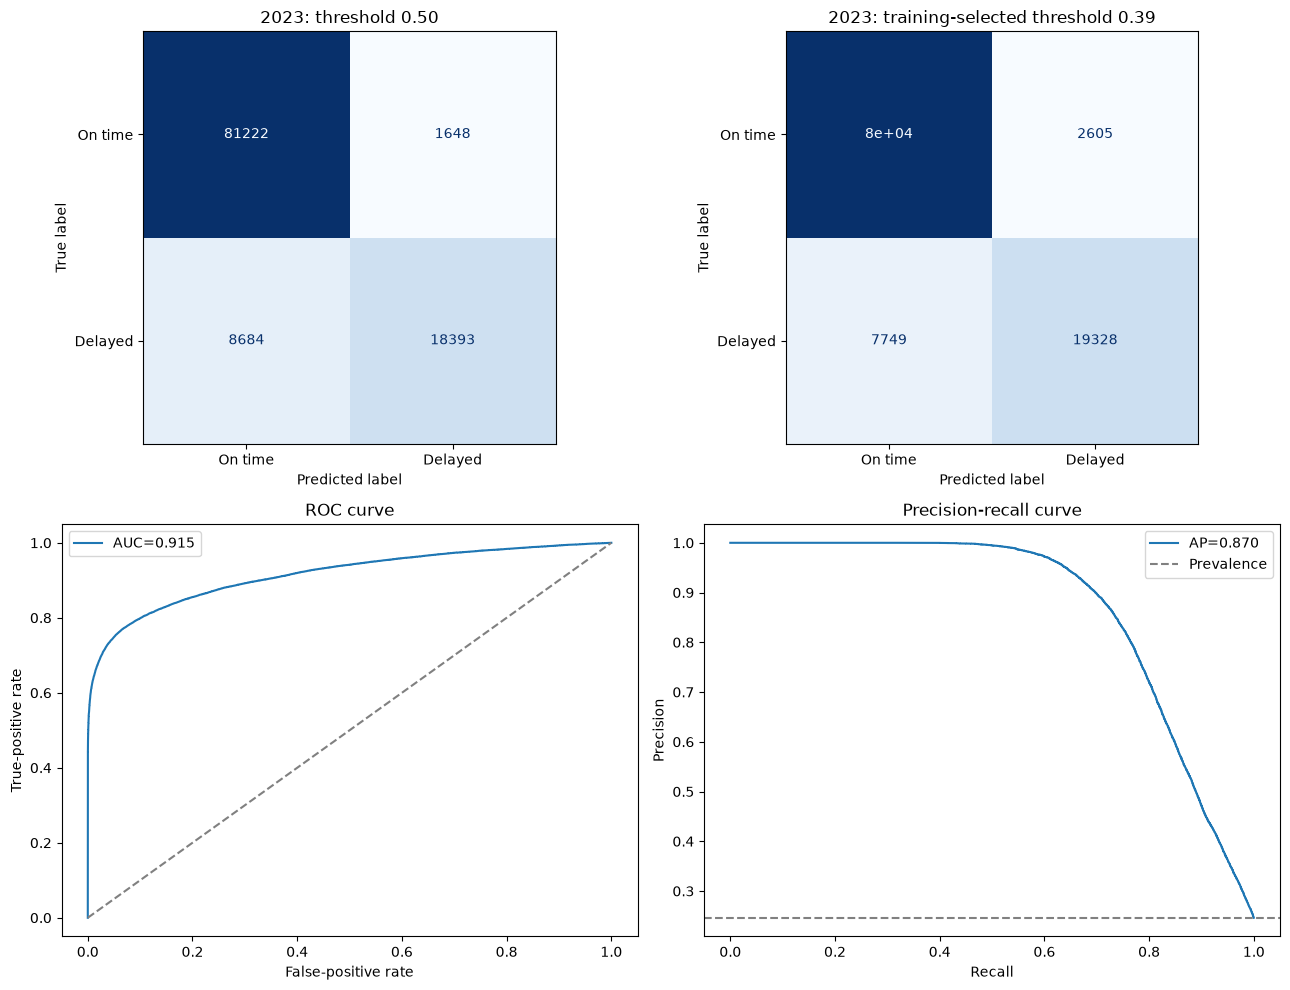

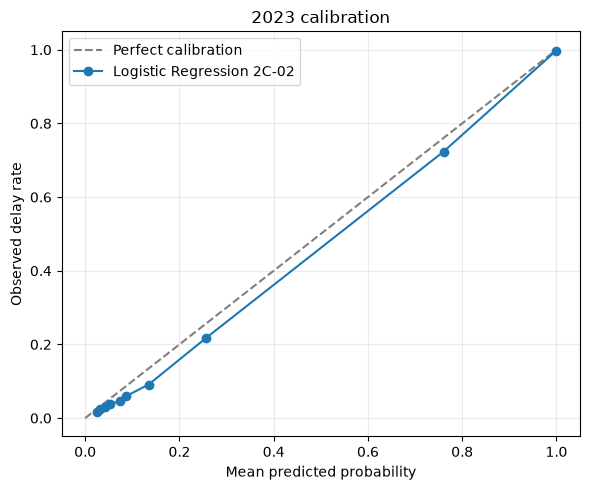

In [10]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="Logistic Regression 2C-02")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect coefficients and publishable values

Coefficient magnitudes describe the fitted standardized representation, not causal effects. Spline-basis coefficients describe ranges of departure delay or schedule margin rather than separate operational effects.


In [11]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["classifier"]
prepared_feature_names = preprocessor.get_feature_names_out()
coefficient_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "coefficient": classifier.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)
display(coefficient_table.head(25))
display(
    coefficient_table[
        coefficient_table["feature"].str.contains(
            "DepDelay|MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK|ACTUAL_DEP_TIME",
            regex=True,
        )
    ]
)

default = evaluation_results.loc["Logistic Regression 2B-02 (default)"]
selected = evaluation_results.loc["Logistic Regression 2B-02 (training-selected)"]
selected_summary = variant_summary.set_index("variant").loc[selected_variant]
publishable_summary = pd.Series({
    "selected variant": selected_variant,
    "source fields": len(variant_source_fields(selected_definition)),
    "calculated model-side fields": int(selected_definition["use_margin_spline"]),
    "prepared predictors": len(prepared_feature_names),
    "selected C": selected_summary["C"],
    "selected penalty": selected_summary["penalty"],
    "selected class weighting": selected_summary["class_weight"],
    "training CV AP": selected_summary["best_mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="Logistic Regression 2B Experiment 02 Appendix F values")
publishable_summary.to_frame()


,feature,coefficient,abs_coefficient
0,numeric__DepDelay,6.3259,6.3259
1,categorical__Reporting_Airline_AS,0.5773,0.5773
2,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.5527,0.5527
3,numeric__SCHEDULED_SPEED_PROXY,0.3176,0.3176
4,numeric__SCHED_ARR_TIME_SIN,-0.2181,0.2181
5,numeric__DAY_OF_YEAR_COS,-0.1243,0.1243
6,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.1190,0.1190
7,categorical__Origin_LAX,-0.1135,0.1135
8,numeric__SCHED_ARR_TIME_COS,0.0877,0.0877
9,numeric__DAY_OF_WEEK_COS,-0.0876,0.0876


,feature,coefficient,abs_coefficient
0,numeric__DepDelay,6.3259,6.3259
2,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.5527,0.5527
6,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.1190,0.1190
37,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000
38,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000
39,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000
40,pushback_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000


,Logistic Regression 2B Experiment 02 Appendix F values
selected variant,pushback_margin_spline
source fields,28
calculated model-side fields,1
prepared predictors,105
selected C,0.0100
selected penalty,l1
selected class weighting,None
training CV AP,0.8653
validation prevalence,0.2463
validation AP,0.8704


## Interpretation checklist

1. Which pushback-time representation wins the 2019 temporal comparison?
2. Does the selected representation improve 2019 average precision over Logistic Regression 2B-01?
3. Does the gain persist in 2023 ranking, probability quality, F1, or MCC?
4. Does actual gate-departure clock information add value beyond signed delay and schedule margin?
5. Is the improvement large enough to replace Experiment 01?
6. Keep the existing feature dataset unchanged and keep 2024 untouched.
